In [1]:
library(xgboost)
library(dplyr)
library(stringr)
build_dataset <- function(feats, labels, offensive = TRUE, successful = TRUE) {
  if (offensive) {
    labels <- labels |> filter(complete == successful) |> select(EVENT_ID, MUID, offense_xG)
  } else {
    labels <- labels |> filter(complete == successful) |> select(EVENT_ID, MUID, defense_xG)
  }

  feats |> inner_join(labels, by = c("EVENT_ID", "MUID"))
}

prepare_training_matrix <- function(passes, offensive = TRUE) {
  label_col <- if (offensive) "offense_xG" else "defense_xG"

  feature_cols <- setdiff(colnames(passes), c("MUID", "EVENT_ID", "X", label_col))
  model_df <- passes |>
    dplyr::select(dplyr::all_of(c(feature_cols, label_col))) |>
    dplyr::filter(!is.na(.data[[label_col]]))   # use chosen label

  mf <- model.frame(
    reformulate(feature_cols, response = label_col),
    data = model_df,
    na.action = na.pass
  )

  X <- model.matrix(
    reformulate(feature_cols, response = NULL, intercept = FALSE),
    data = mf
  )

  list(
    X = X,
    y = model_df[[label_col]],
    feature_cols = colnames(X)
  )
}



Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



In [2]:
#feats_mat <- feats_all |> select(-c("event_id", "match_id")) |> xgb.DMatrix()
model <- xgb.load("/home/lz80/rdf/sp161/shared/soccer-decision-making-r/sportec/xgb_offense_successful.json")
feats <- read.csv("/home/lz80/rdf/sp161/shared/soccer-decision-making-r/sportec/xgb_features.csv") |>
  rename(
    EVENT_ID = event_id,
    MUID = match_id
  ) |>
  mutate(
    MUID = str_sub(MUID, 1, -4 - 1)
  )

labels <- read.csv("/home/lz80/rdf/sp161/shared/soccer-decision-making-r/sportec/xgb_labels.csv")
passes <- build_dataset(feats, labels, offensive = TRUE)
print("built dataset")
prepared <- prepare_training_matrix(passes)
X <- prepared$X
y <- prepared$y

[1] "built dataset"


In [6]:
preds = predict(model, X)



predictions = passes |> mutate(
  prediction = preds
)
feature_list <- (feats |> colnames())[-c(1,2,3)]

library(ggplot2)

In [7]:
feature_list
important = c("p_dist_from_goal", "i_dist_from_goal", "p_angle", "i_angle", "num_def_pr")

In [9]:
pdf("feature_plots.pdf", width = 8, height = 6)
c = 1
for (feature in feature_list) {
  p <- predictions |>
    ggplot(aes(x = .data[[feature]], y = prediction)) +
    geom_point() +
    labs(title = paste("xG vs", feature), x = feature, y = "prediction")
  print(p)
  print(paste0(c, "/", length(feature_list)))
  c = c + 1
}

dev.off()


[1] "1/62"
[1] "2/62"
[1] "3/62"
[1] "4/62"
[1] "5/62"
[1] "6/62"
[1] "7/62"
[1] "8/62"
[1] "9/62"
[1] "10/62"
[1] "11/62"
[1] "12/62"
[1] "13/62"
[1] "14/62"
[1] "15/62"
[1] "16/62"
[1] "17/62"
[1] "18/62"
[1] "19/62"
[1] "20/62"
[1] "21/62"
[1] "22/62"
[1] "23/62"
[1] "24/62"
[1] "25/62"
[1] "26/62"
[1] "27/62"
[1] "28/62"
[1] "29/62"
[1] "30/62"
[1] "31/62"
[1] "32/62"
[1] "33/62"
[1] "34/62"
[1] "35/62"
[1] "36/62"
[1] "37/62"
[1] "38/62"
[1] "39/62"
[1] "40/62"
[1] "41/62"
[1] "42/62"
[1] "43/62"
[1] "44/62"
[1] "45/62"
[1] "46/62"
[1] "47/62"
[1] "48/62"
[1] "49/62"
[1] "50/62"
[1] "51/62"
[1] "52/62"
[1] "53/62"
[1] "54/62"
[1] "55/62"
[1] "56/62"
[1] "57/62"
[1] "58/62"
[1] "59/62"
[1] "60/62"
[1] "61/62"
[1] "62/62"


There were 48 warnings (use warnings() to see them)


null device 
          1 

In [ ]:
library(dplyr)
library(arrow)
library(ggplot2)
library(xml2)
library(ggsoccer)
library(tidyr)
library(purrr)
library(progress)
library(xgboost)
library(bit64)

build_features <- function(event_df, event) {
  team <- event_df |> filter(player_team == "ATTACK", object_id != player_id)
  players <- team |> pull(object_id) |> unique()
  player_dfs <- vector("list", length(players))

  for (i in seq_along(players)) {
    player <- players[[i]]
    event_player_id <- paste(event, player, sep = "_")

    player_dfs[[i]] <- event_df |>
      mutate(
        event_id = event_player_id,
        is_intended = (object_id == player)
      )
  }
  bind_rows(player_dfs)
}

get_results <- function(frames, event, match){
  event_df <- frames |> filter(event_id == event, match_id == match) |> mutate(
    player_side = ifelse(player_team == team_id, "ATTACK", ifelse(player_team == "BALL", "BALL", "DEFENSE"))
  )
  expanded_events <- event_df |> build_features(event)

  group_ids <- interaction(expanded_events$match_id, expanded_events$event_id, drop = TRUE)
  group_index <- split(seq_len(nrow(expanded_events)), group_ids, drop = TRUE)

  feats_all <- purrr::map_dfr(group_index, function(ix) {
    event_df <- expanded_events[ix, , drop = FALSE]
    eid <- event_df$event_id[[1]]
    mid <- event_df$match_id[[1]]

    tryCatch(
      calc_event_features(event_df) |> mutate(event_id = eid, match_id = mid, .before = 1),
      error = function(e) {
        message(sprintf("Error in event_id %s: %s", eid, conditionMessage(e)))
        tibble()
      }
    )
  })
  return(feats_all)
  feats_mat <- feats_all |> select(-c("event_id", "match_id")) |> xgb.DMatrix()
  model <- xgb.load("/home/lz80/rdf/sp161/shared/soccer-decision-making-r/sportec/xgb_offense_successful.json")
  preds <- predict(model, feats_mat)
  results <- feats_all |> select(event_id, match_id) |>
    separate(
      col = event_id,
      into = c("event_id", "object_id"),
      sep = "_",
      extra = "merge"
    ) |> mutate(
    prediction = preds,
    event_id = as.integer64(event_id)
  )
  coord_df <- event_df |> left_join(results, by = c("event_id","match_id", "object_id")) |> 
    select(x, y, ball_x_10frame_forward, ball_y_10frame_forward, player_side, prediction)
  coord_df
}
feature_script <- "/home/lz80/soccer-decision-making-r/scripts/generate_xgb_features.r"
feature_lines <- readLines(feature_script)#there is probably a better way to do this...
cut_idx <- grep("^goal_coords", feature_lines)[1] - 1

eval(parse(text = feature_lines[1:cut_idx]), envir = .GlobalEnv)
goal_coords <- c(x = 52.5, y = 0)

frames <- read_parquet("/home/lz80/rdf/sp161/shared/soccer-decision-making-r/sportec/passes.parquet") |> filter(is.na(set_piece_type)) |> mutate(
  x_velo = x_p5 - x_m5,
  y_velo = y_p5 - y_m5
)

event = 18477700000007
match = "DFL-MAT-J03YKP.xml"
pitch_sportec <- list(
  length = 105,
  width = 68,
  penalty_box_length = 16.5,
  penalty_box_width = 40.32,
  six_yard_box_length = 5.5,
  six_yard_box_width = 18.32,
  penalty_spot_distance = 11,
  goal_width = 7.32,
  origin_x = -52.5,
  origin_y = -34
)
event_df <- frames |> filter(event_id == event, match_id == match) |> mutate(
    player_team = ifelse(player_team == team_id, "ATTACK", ifelse(player_team == "BALL", "BALL", "DEFENSE"))
  )
expanded_events <- event_df |> build_features(event)


In [30]:
expanded_events |> filter(position == "TW", player_team == "ATTACK") |> select(object_id)
gk = "DFL-OBJ-J013RO"
event_id = 18477700000007
coord_df <- frames |> get_results(event, match)


In [35]:
sqrt((36.1 - 52.5)^2 + (-0.48 - 0)**2)

[1] 16.40702

# A tibble: 87 × 2
   event_id match_id          
    <int64> <chr>             
 1    1.e13 DFL-MAT-J03YKP.xml
 2    1.e13 DFL-MAT-J03YKP.xml
 3    1.e13 DFL-MAT-J03YKP.xml
 4    1.e13 DFL-MAT-J03YKP.xml
 5    1.e13 DFL-MAT-J03YKP.xml
 6    1.e13 DFL-MAT-J03YKP.xml
 7    1.e13 DFL-MAT-J03YKP.xml
 8    1.e13 DFL-MAT-J03YKP.xml
 9    1.e13 DFL-MAT-J03YKP.xml
10    1.e13 DFL-MAT-J03YKP.xml
# ℹ 77 more rows
# ℹ Use `print(n = ...)` to see more rows

In [34]:
expanded_events |> filter(position == "TW", player_team == "ATTACK") |> select(x, y)


# A tibble: 10 × 2
       x     y
   <dbl> <dbl>
 1  36.1 -0.48
 2  36.1 -0.48
 3  36.1 -0.48
 4  36.1 -0.48
 5  36.1 -0.48
 6  36.1 -0.48
 7  36.1 -0.48
 8  36.1 -0.48
 9  36.1 -0.48
10  36.1 -0.48

In [ ]:
coord_df |> filter(event_id == "18477700000007_DFL-OBJ-J013RO") |> 

# A tibble: 1 × 64
  event_id   match_id p_dist_from_goal p_angle i_dist_from_goal i_angle i_x_velo
  <chr>      <chr>               <dbl>   <dbl>            <dbl>   <dbl>    <dbl>
1 184777000… DFL-MAT…             33.7   0.850             16.4    1.68   -0.350
# ℹ 57 more variables: i_y_velo <dbl>, pr_dist <dbl>, pr_angle <dbl>,
#   pr_x_rel_velo <dbl>, pr_y_rel_velo <dbl>, num_att_pr <int>,
#   num_def_pr <int>, num_att_rg <int>, num_def_rg <int>,
#   dist_behind_1_d <dbl>, dist_behind_2_d <dbl>, dist_infront_1_d <dbl>,
#   dist_infront_2_d <dbl>, angle_behind_1_d <dbl>, angle_behind_2_d <dbl>,
#   angle_infront_1_d <dbl>, angle_infront_2_d <dbl>,
#   x_rel_velo_behind_1_d <dbl>, x_rel_velo_behind_2_d <dbl>, …

In [112]:
#
results <- feats_all |> select(event_id, match_id) |>
  separate(
    col = event_id,
    into = c("event_id", "object_id"),
    sep = "_",
    extra = "merge"
  ) |> mutate(
  prediction = preds,
  event_id = as.integer64(event_id)
)
coord_df <- event_df |> left_join(results, by = c("event_id","match_id", "object_id")) |> select(x, y, ball_x_10frame_forward, ball_y_10frame_forward, player_team, prediction)

In [ ]:
flip_event <- function(event_df){
  gk_x_t <- event_df |> filter(position == 'TW' & player_team == team_id) |> pull(x)
  gk_x_opp <- event_df |> filter(position == 'TW' & player_team != team_id) |> pull(x)
  print(gk_x_t)
  print(gk_x_opp)
  needs_flip <- length(gk_x_t) > 0 && (gk_x_t[[1]] > gk_x_opp[[1]])

  if (needs_flip) {
    event_df <- event_df |>
      mutate(
        x = -x,
        ball_x_10frame_forward = -ball_x_10frame_forward,
        ball_x_10frame_forward_p5 = -ball_x_10frame_forward_p5,
        x_p5 = -x_p5,
        x_m5 = -x_m5,
        x_rec = -x_rec,
        x_velo = -x_velo
      )
  }
  event_df <- event_df |> mutate(
      dist_from_goal = sqrt((x - goal_coords["x"])**2 + (y - goal_coords["y"])**2)
  )
  return(needs_flip)
}
flip_event(event_df)

[1] -41.01  36.14


[1] FALSE

In [ ]:
event_df |> filter(position == 'TW' & player_team == team_id)

# A tibble: 23 × 65
   event_id event_type period_id timestamp  end_timestamp ball_state
    <int64> <chr>          <int> <drtn>             <???> <chr>     
 1    1.e13 PASS               1 2.438 secs             . alive     
 2    1.e13 PASS               1 2.438 secs             . alive     
 3    1.e13 PASS               1 2.438 secs             . alive     
 4    1.e13 PASS               1 2.438 secs             . alive     
 5    1.e13 PASS               1 2.438 secs             . alive     
 6    1.e13 PASS               1 2.438 secs             . alive     
 7    1.e13 PASS               1 2.438 secs             . alive     
 8    1.e13 PASS               1 2.438 secs             . alive     
 9    1.e13 PASS               1 2.438 secs             . alive     
10    1.e13 PASS               1 2.438 secs             . alive     
# ℹ 13 more rows
# ℹ 59 more variables: ball_owning_team <???>, team_id <chr>, player_id <chr>,
#   coordinates_x <dbl>, coordinates_y <dbl>, end_coordi

In [119]:
labels <- read.csv("/home/lz80/rdf/sp161/shared/soccer-decision-making-r/sportec/xgb_labels.csv")

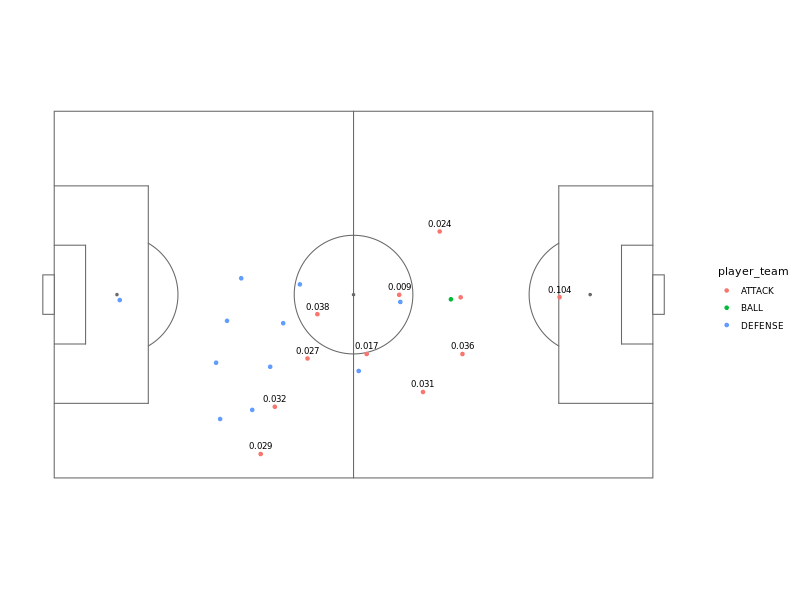

In [ ]:
pitch_sportec <- list(
  length = 105,
  width = 68,
  penalty_box_length = 16.5,
  penalty_box_width = 40.32,
  six_yard_box_length = 5.5,
  six_yard_box_width = 18.32,
  penalty_spot_distance = 11,
  goal_width = 7.32,
  origin_x = -52.5,
  origin_y = -34
)


coord_df |> ggplot() + annotate_pitch(dimension = pitch_sportec) + geom_point(aes(x = x, y = y, col = player_team)) + geom_text(
    data = coord_df |> dplyr::filter(!is.na(prediction)),
    aes(x = x, y = y, label = sprintf("%.3f", prediction)),
    nudge_y = 1.5,
    size = 3
  ) + theme_pitch() 

In [122]:
labels |> summarise(
  mean(abs((offense_xG - mean(offense_xG))))
)

  mean(abs((offense_xG - mean(offense_xG))))
1                                 0.02188535